<a href="https://colab.research.google.com/github/kritikamandale/Python_is_a_language/blob/main/Day7_DL(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tensorflow

In [ ]:
from tensorflow.keras.datasets import mnist
mnist_data = mnist.load_data()
type(mnist_data)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


tuple

In [ ]:
from tensorflow import train
(train_images, train_labels), (test_images, test_labels) = mnist_data

In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
train_images.ndim

3

In [ ]:
train_labels.shape

(60000,)

In [ ]:
test_images.shape

(10000, 28, 28)

In [ ]:
test_labels.ndim

1

In [ ]:
test_labels.shape

(10000,)

Text(0.5, 1.0, 'this digit is : 7')

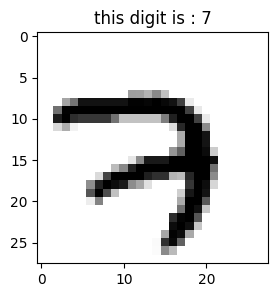

In [ ]:
#visualizing the image
import matplotlib.pyplot as plt
plt.figure(figsize = (4,3))
plt.imshow(train_images[5000],cmap ='binary')
plt.title(f"this digit is : {train_labels[5000]}")

In [ ]:
train_images[0].max()

np.uint8(255)

In [ ]:
#Reshape and normalize the array
train_images_scaled = train_images.reshape((60000,28*28))/255.0
test_images_scaled = test_images.reshape((10000,28*28))/255.0

In [ ]:
train_images_scaled[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [32]:
#Creating a neural network architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
digit_nn_model = Sequential()
digit_nn_model.add(Dense(256  , activation='relu'))
digit_nn_model.add(Dropout(0.2))
digit_nn_model.add(Dense(128, activation = 'relu'))
digit_nn_model.add(Dropout(0.2))
digit_nn_model.add(Dense(10, activation = 'softmax'))  #output layer

In [34]:
digit_nn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [35]:
#train the model
#training the NN model
history = digit_nn_model.fit(train_images_scaled,train_labels, epochs = 40,
                             batch_size = 64, validation_split= 0.2)

Epoch 1/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8345 - loss: 0.5463 - val_accuracy: 0.9586 - val_loss: 0.1383
Epoch 2/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9550 - loss: 0.1464 - val_accuracy: 0.9677 - val_loss: 0.1063
Epoch 3/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9693 - loss: 0.1015 - val_accuracy: 0.9718 - val_loss: 0.0956
Epoch 4/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9750 - loss: 0.0798 - val_accuracy: 0.9755 - val_loss: 0.0839
Epoch 5/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9784 - loss: 0.0681 - val_accuracy: 0.9756 - val_loss: 0.0811
Epoch 6/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9826 - loss: 0.0542 - val_accuracy: 0.9763 - val_loss: 0.0851
Epoch 7/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9827 - loss: 0.0497 - val_accuracy: 0.9785 - val_loss: 0.0790
Epoch 8/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9850 - loss: 0.0461 - val_accuracy: 

In [36]:
digit_nn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (64, 256)              │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (64, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (64, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (64, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (64, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705,440 (2.69 MB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 470,294 (1.79 MB)

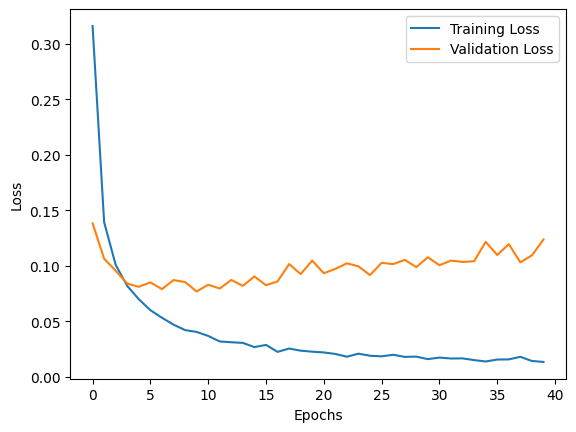

In [40]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [41]:
#Evaluate the test
loss, acc = digit_nn_model.evaluate(test_images_scaled, test_labels)
print(f"Accuracy of the model is: {acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9799 - loss: 0.1260
Accuracy of the model is: 98.31%


In [42]:
#test the model
x_new = test_images_scaled[:3]
prediction = digit_nn_model.predict(x_new)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


array([[1.9237268e-19, 4.1206336e-17, 3.5479073e-14, 8.9950833e-15,
        4.9850885e-26, 4.4756468e-20, 2.1444748e-28, 1.0000000e+00,
        2.0633978e-22, 2.6623887e-14],
       [3.0942147e-18, 1.8997452e-15, 1.0000000e+00, 6.5093981e-19,
        2.1369038e-29, 1.6632176e-24, 3.0897555e-26, 3.5022541e-22,
        1.9490946e-17, 1.1476147e-34],
       [8.1459921e-16, 1.0000000e+00, 2.4879518e-17, 2.6244983e-22,
        9.8635069e-14, 2.2498035e-18, 1.1434833e-11, 2.3080093e-12,
        9.2907051e-13, 5.5540739e-21]], dtype=float32)

In [43]:
prediction[0].argmax()

np.int64(7)

Text(0.5, 1.0, 'This digit is:7')

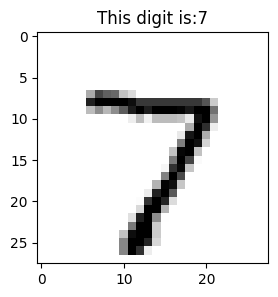

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.imshow(test_images[0], cmap='binary')
plt.title(f"This digit is:{test_labels[0]}")

In [46]:
digit_nn_model.save('digit_nn_model.keras')

In [47]:
from tensorflow.keras.models import load_model
model = load_model('/content/digit_nn_model.keras')

In [ ]:
############################################################################################################################

In [ ]:
from sklearn.preprocessing